In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
eval_df = pd.read_csv("predictions/claude_prediction_df.csv")
eval_df.columns

Index(['citing_cluster_id', 'citing_url', 'cited_cluster_id', 'cited_url',
       'cited_case_name_short', 'cited_case_name', 'cited_citations', 'expert',
       'expert_label', 'expert_notes', 'citing_filenames', 'targetName',
       'targetHistory', 'targetTreatment', 'quote', 'rationale'],
      dtype='object')

In [6]:
eval_df = eval_df[~eval_df["targetTreatment"].isnull()]

# Run evaluation

In [7]:
eval_df["expert_label"].value_counts()

expert_label
Cited by                   6
Vacated and remanded by    1
Abrogated by               1
Name: count, dtype: int64

In [8]:
eval_df["targetTreatment"].value_counts()

targetTreatment
Cited by                   5
Vacated by                 1
Questioned by              1
Vacated and remanded by    1
Name: count, dtype: int64

In [9]:
y_true = eval_df["expert_label"]
y_pred = eval_df["targetTreatment"]

In [10]:
report = classification_report(y_true, y_pred)
print(report)

                         precision    recall  f1-score   support

           Abrogated by       0.00      0.00      0.00         1
               Cited by       1.00      0.83      0.91         6
          Questioned by       0.00      0.00      0.00         0
Vacated and remanded by       0.00      0.00      0.00         1
             Vacated by       0.00      0.00      0.00         0

               accuracy                           0.62         8
              macro avg       0.20      0.17      0.18         8
           weighted avg       0.75      0.62      0.68         8



/Users/rachel/anaconda3/envs/citator/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rachel/anaconda3/envs/citator/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rachel/anaconda3/envs/citator/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

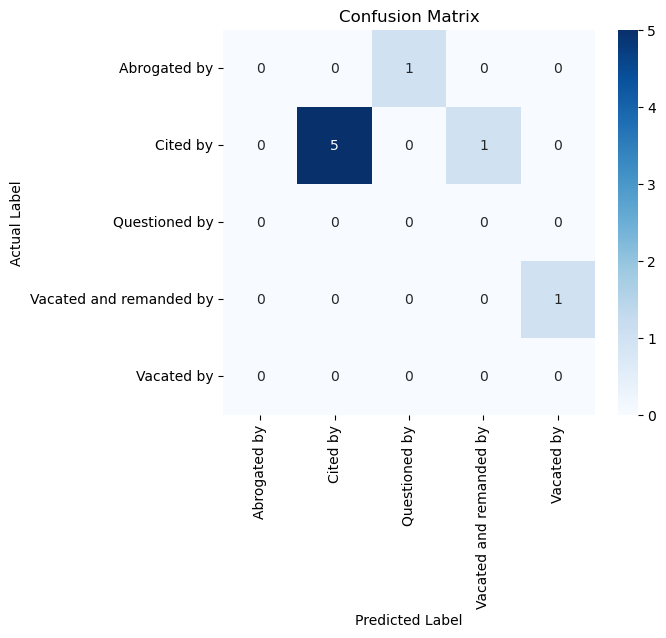

In [11]:
labels = sorted(list(set(y_true) | set(y_pred)))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Plot confusion matrix using seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()